In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant
LOCAL_DATA_DIR = "/home/dnanexus/data_dir/"

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o {LOCAL_DATA_DIR}/{olink_burden_test_file}

olink_whitelist = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
olink_correlations_file = "olink_LOFTEE_correlations_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o {LOCAL_DATA_DIR}/{olink_correlations_file}

olink_corrs = (
    pl.read_parquet(f'{LOCAL_DATA_DIR}/{olink_correlations_file}')
    .filter(pl.col('correlation')>0)
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir//proteomics_prs_df_loftee_mac20_burden_re
gression_results.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir//olink_LOFTEE_correlations_protrider_t_df
_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet" already exists
but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000131471""","""ENSG00000131471_olink""",0.16163,0.16163,1.0
"""ENSG00000143382""","""ENSG00000143382_olink""",0.154266,0.154266,1.0
"""ENSG00000099994""","""ENSG00000099994_olink""",0.148376,0.148376,1.0
"""ENSG00000213927""","""ENSG00000213927_olink""",0.147887,0.147887,1.0
"""ENSG00000174080""","""ENSG00000174080_olink""",0.147505,0.147505,1.0
…,…,…,…,…
"""ENSG00000168079""","""ENSG00000168079_olink""",0.002397,0.002397,1.0
"""ENSG00000149564""","""ENSG00000149564_olink""",0.001879,0.001879,1.0
"""ENSG00000141736""","""ENSG00000141736_olink""",0.0014,0.0014,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#FFD700""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FFA500""","""ESM1v""",-1
"""missense""","""esm1b_llr""","""#FF6600""","""ESM1b""",-1
"""missense""","""cpt1_llr""","""#E63000""","""CPT-1""",1
…,…,…,…,…
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#1f77b4""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_blood_max""","""crimson""","""Flashzoi max across RNA (blood…",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_all_min', 'fz_all_max', 'fz_all_mean'])
    .collect()
)

new_anno_df

Error: path "/home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants
_all_260218_0_ukbbgym.parquet" already exists but -f/--overwrite was not set


/tmp/ipykernel_659851/920274466.py:18: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_all_min,fz_all_max,fz_all_mean
str,str,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.006898,0.001423,0.000735
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.013746,0.019601,0.00242
"""chr12:10309195:A:G""","""ENSG00000134539""",-0.01001,0.074744,0.016764
"""chr2:162198524:G:A""","""ENSG00000078098""",-0.002404,0.021105,0.005209
"""chr12:132769639:G:C""","""ENSG00000090615""",-0.004555,0.02279,0.001099
…,…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.033511,0.107099,0.013249
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.021009,0.002934,0.003397
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,0.002198,0.000479


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
# keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # VEP consequences
        # (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('ted_domain') == False),
        # (pl.col('mobi_full_disorder_priority') == True),
        # (pl.col('mobi_full_lip_priority') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Choose regulatory region
        # (pl.col('pangolin_score') < 0.2), # Remove splice variants from the regulatory analysis
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),
        # (pl.col('encode_any_tf') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories = ['missense'] # missense
# selected_categories = ['splicing'] # splicing
# selected_categories = ['regulatory'] # regulatory
selected_categories = ['genetic_diversity', 'conservation'] # genome-wide

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_659851/1820781874.py:85: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_659851/1820781874.py:94: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


gpn_score,cadd_raw,id,verphylop,region
f32,f32,str,f32,str
-1.51,0.122935,"""chr8:133085829:A:C""",0.301,"""ENSG00000042832"""
0.51,0.248169,"""chr7:116748342:G:A""",0.345,"""ENSG00000105976"""
-2.45,0.420645,"""chr1:107758751:A:C""",0.892,"""ENSG00000134215"""
-2.16,0.297144,"""chr5:78193372:T:C""",-0.103,"""ENSG00000132842"""
-0.09,0.677827,"""chr7:16830530:A:G""",0.116,"""ENSG00000106541"""
…,…,…,…,…
-1.58,0.859698,"""chr2:240434180:G:C""",0.114,"""ENSG00000063660"""
-0.71,0.582003,"""chr2:88650991:C:T""",-0.359,"""ENSG00000172071"""
-0.07,-0.71133,"""chr7:148374033:C:T""",-0.739,"""ENSG00000174469"""


In [6]:
anno_fillna = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .with_columns(
        promoterai_under_is_na = pl.col('promoterai_is_na'),
        promoterai_over_is_na = pl.col('promoterai_is_na'),
    )
)
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_659851/3954935598.py:35: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr2:37129304:C:G""","""ENSG00000055332""","""verphylop""",1
"""chr4:17459787:T:C""","""ENSG00000151552""","""verphylop""",1
"""chr13:101671728:G:A""","""ENSG00000198542""","""verphylop""",1
"""chr2:165812954:A:G""","""ENSG00000115339""","""verphylop""",1
"""chr5:78868999:C:T""","""ENSG00000113273""","""verphylop""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Remove variants for each annotation which are not scored
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        # annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="ordinal", descending=True).over(["annotation"]).cast(pl.Float32)
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_659851/3977662353.py:46: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr5:148033671:A:G""","""ENSG00000133710""","""cadd_raw""",0.149132,"""genetic_diversity""",1,1.1574319e7
"""chr21:33606095:T:C""","""ENSG00000205758""","""cadd_raw""",0.004978,"""genetic_diversity""",1,1.4422495e7
"""chr5:309067:T:C""","""ENSG00000249915""","""cadd_raw""",0.295218,"""genetic_diversity""",1,8.2781e6
"""chr1:117516178:C:G""","""ENSG00000198162""","""cadd_raw""",1.16345,"""genetic_diversity""",1,1.390828e6
"""chr11:100218796:A:G""","""ENSG00000149972""","""cadd_raw""",0.323037,"""genetic_diversity""",1,7.696134e6
…,…,…,…,…,…,…
"""chr3:60451430:G:A""","""ENSG00000189283""","""cadd_raw""",-0.201347,"""genetic_diversity""",1,1.7206532e7
"""chr7:130304214:T:C""","""ENSG00000128510""","""cadd_raw""",0.997504,"""genetic_diversity""",1,1.80517e6
"""chr2:114829822:T:G""","""ENSG00000175497""","""cadd_raw""",0.61633,"""genetic_diversity""",1,3.752311e6


In [8]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [9]:
olink_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",0.328067,1
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",-1.312343,1
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",0.249114,1
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1.00197,1
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",-0.059154,1


## Average z-score by annotation rank (sliding window)

In [10]:
# Sliding window and bootstrap parameters
window_size = 1_000  # Number of variants in the sliding window
step_size = 1_0      # Step between sampled points (controls plot smoothness)
max_num_variants = 500_000

# LOEUF faceting
n_loeuf_bins = 4  # Number of LOEUF bins (default 4)
n_boot = 1000      # Number of bootstrap resamples across regions

# Load gnomAD constraint metrics and create LOEUF bins
gnom = (
    pl.read_csv(
        "/home/dnanexus/data_dir/gnomad.v4.1.constraint_metrics.tsv", 
        null_values=["NA"],
        separator='\t'
    )
    .filter(
        pl.col('transcript_type')=='protein_coding',
        pl.col('canonical')==True
    )
    .select(['gene_id', 'lof.oe_ci.upper'])
    .rename({'gene_id': 'region', 'lof.oe_ci.upper': 'loeuf'})
    .drop_nulls()
)

loeuf_labels = [
    f'Q{i+1} (most constrained)' if i == 0
    else f'Q{i+1} (least constrained)' if i == n_loeuf_bins - 1
    else f'Q{i+1}'
    for i in range(n_loeuf_bins)
]

loeuf_bins = gnom.with_columns(
    loeuf_bin = pl.col('loeuf').qcut(n_loeuf_bins, labels=loeuf_labels)
)

loeuf_bins

region,loeuf,loeuf_bin
str,f64,cat
"""ENSG00000121410""",1.34,"""Q4 (least constrained)"""
"""ENSG00000148584""",0.825,"""Q2"""
"""ENSG00000175899""",0.765,"""Q2"""
"""ENSG00000166535""",0.953,"""Q2"""
"""ENSG00000184389""",1.529,"""Q4 (least constrained)"""
…,…,…
"""ENSG00000288914""",1.87,"""Q4 (least constrained)"""
"""ENSG00000289027""",0.885,"""Q2"""
"""ENSG00000289258""",0.982,"""Q3"""


In [11]:
# --- Helper functions ---

def sliding_window_means_unweighted(zscores, bin_ends, window_size):
    """Standard prefix-sum sliding window mean (for point estimates)."""
    csum = np.empty(len(zscores) + 1, dtype=np.float64)
    csum[0] = 0.0
    np.cumsum(zscores, out=csum[1:])
    return (csum[bin_ends] - csum[bin_ends - window_size]) / window_size


def expanded_csum_at(positions, cw, cwz, z, N):
    """Compute the prefix sum of the virtual expanded array at given positions."""
    k = np.searchsorted(cw, positions, side='left')
    k_safe = np.clip(k, 1, N)
    result = cwz[k_safe - 1] + z[k_safe - 1] * (positions - cw[k_safe - 1])
    result = np.where(positions <= 0, 0.0, result)
    return result


def sliding_window_reranked(z, cw, cwz, N, total_expanded, bin_ends, window_size):
    """Sliding window mean on the virtual expanded (re-ranked) array."""
    valid_mask = bin_ends <= total_expanded
    valid_bins = bin_ends[valid_mask]
    means = np.full(len(bin_ends), np.nan, dtype=np.float64)
    if len(valid_bins) == 0:
        return means
    right = expanded_csum_at(valid_bins, cw, cwz, z, N)
    left = expanded_csum_at(valid_bins - window_size, cw, cwz, z, N)
    means[valid_mask] = (right - left) / window_size
    return means


# --- Join olink_whitelist with LOEUF bins ---
olink_whitelist_loeuf = olink_whitelist.join(loeuf_bins, on='region', how='inner')

bin_counts = (
    olink_whitelist_loeuf
    .select(['region', 'loeuf_bin'])
    .unique(subset=['region'])
    .group_by('loeuf_bin')
    .len()
)
bin_label_map = {row[0]: f"{row[0]} (n={row[1]})" for row in bin_counts.iter_rows()}

id_region = anno.select(['id', 'region']).unique().lazy()

# --- Loop over LOEUF bins ---
all_zscore_binned = []

for loeuf_bin_raw, loeuf_bin_label in sorted(bin_label_map.items()):
    print(f"\n{'='*60}")
    print(f"Processing: {loeuf_bin_label}")
    print(f"{'='*60}")

    # Filter olink_whitelist to this bin
    wl_bin = olink_whitelist_loeuf.filter(pl.col('loeuf_bin') == loeuf_bin_raw)
    bin_regions = wl_bin['region'].unique()

    # Filter melted_anno to this bin's regions and re-rank within the subset
    melted_anno_bin = (
        melted_anno
        .filter(pl.col('region').is_in(bin_regions))
        .with_columns(
            annotation_score_dircor = pl.col('annotation_score') * pl.col('annotation_dir').cast(pl.Float32)
        )
        .with_columns(
            annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor')
                .rank(method="max", descending=True)
                .over("annotation")
                .cast(pl.Float32)
        )
        .drop('annotation_score_dircor')
    )

    # Variant z-scores for this bin
    variant_zscores = (
        olink_appv
        .join(id_region, on='id', how='inner')
        .join(wl_bin.lazy(), on=['region', 'phenotype'], how='inner')
        .select(['id', 'region', 'mean_pheno_value'])
        .collect(engine='streaming')
    )
    print(f"  Variant z-scores: {variant_zscores.shape[0]} variant-gene pairs")

    # Ranked z-scores
    ranked_zscores = (
        variant_zscores.lazy()
        .join(
            melted_anno_bin.lazy().select(['id', 'region', 'annotation', 'annotation_score_dircor_rank_desc']),
            on=['id', 'region'],
            how='inner'
        )
        .sort(['annotation', 'annotation_score_dircor_rank_desc'])
        .with_columns(
            row_pos = pl.col('annotation').cum_count().over('annotation'),
        )
        .pipe(lambda df: df.filter(pl.col('row_pos') <= max_num_variants) if max_num_variants is not None else df)
        .collect(engine='streaming')
    )

    # Map regions to integer indices for fast bootstrap resampling
    bin_all_regions = sorted(wl_bin['region'].unique().to_list())
    bin_n_regions = len(bin_all_regions)
    region_idx_map = pl.DataFrame({'region': bin_all_regions, '_region_idx': np.arange(bin_n_regions, dtype=np.int32)})
    ranked_zscores = ranked_zscores.join(region_idx_map, on='region', how='left')

    annotations_list = sorted(ranked_zscores['annotation'].unique().to_list())

    # --- Prepare per-annotation sorted arrays and bin endpoints ---
    anno_arrays = {}
    for annotation in tqdm(annotations_list, desc=f'  Preparing arrays'):
        adf = ranked_zscores.filter(pl.col('annotation') == annotation)
        z = adf['mean_pheno_value'].to_numpy().astype(np.float64)
        r_idx = adf['_region_idx'].to_numpy()
        N = len(z)
        bin_ends = np.arange(window_size, N + 1, step_size, dtype=np.int64)
        anno_arrays[annotation] = {
            'zscores': z,
            'region_idx': r_idx,
            'bin_ends': bin_ends,
            'N': N,
        }

    # --- Point estimates (unweighted, on full data) ---
    point_means = {}
    for annotation in annotations_list:
        d = anno_arrays[annotation]
        point_means[annotation] = sliding_window_means_unweighted(
            d['zscores'], d['bin_ends'], window_size
        )

    # --- Re-ranking bootstrap CIs across regions ---
    rng = np.random.default_rng(42)
    boot_means = {ann: np.full((n_boot, len(anno_arrays[ann]['bin_ends'])), np.nan)
                  for ann in annotations_list}

    max_N = max(d['N'] for d in anno_arrays.values())
    cw_buf = np.empty(max_N + 1, dtype=np.float64)
    cwz_buf = np.empty(max_N + 1, dtype=np.float64)

    for b in tqdm(range(n_boot), desc=f'  Bootstrap'):
        idx = rng.choice(bin_n_regions, size=bin_n_regions, replace=True)
        region_weights = np.bincount(idx, minlength=bin_n_regions).astype(np.float64)

        for annotation in annotations_list:
            d = anno_arrays[annotation]
            N = d['N']
            z = d['zscores']
            vw = region_weights[d['region_idx']]

            cw = cw_buf[:N + 1]
            cw[0] = 0.0
            np.cumsum(vw, out=cw[1:])

            cwz = cwz_buf[:N + 1]
            cwz[0] = 0.0
            np.cumsum(z * vw, out=cwz[1:])

            total_expanded = int(cw[N])

            boot_means[annotation][b] = sliding_window_reranked(
                z, cw, cwz, N, total_expanded, d['bin_ends'], window_size
            )

    # --- Build output DataFrame with percentile-based CIs ---
    bin_results = []
    for annotation in annotations_list:
        d = anno_arrays[annotation]
        bm = boot_means[annotation]
        bin_results.append(pl.DataFrame({
            'annotation': annotation,
            'bin_end': d['bin_ends'].astype(np.float64),
            'mean_zscore': point_means[annotation].astype(np.float32),
            'ci_lower': np.nanpercentile(bm, 2.5, axis=0).astype(np.float32),
            'ci_upper': np.nanpercentile(bm, 97.5, axis=0).astype(np.float32),
        }))

    zscore_binned_bin = (
        pl.concat(bin_results)
        .sort(['annotation', 'bin_end'])
        .with_columns(loeuf_bin=pl.lit(loeuf_bin_label))
    )
    print(f"  Sliding window results: {zscore_binned_bin.shape[0]} points across {zscore_binned_bin['annotation'].n_unique()} annotations")
    all_zscore_binned.append(zscore_binned_bin)

zscore_binned = pl.concat(all_zscore_binned).sort(['loeuf_bin', 'annotation', 'bin_end'])
print(f"\nTotal: {zscore_binned.shape[0]} points across {zscore_binned['loeuf_bin'].n_unique()} LOEUF bins")
zscore_binned


Processing: Q1 (most constrained) (n=177)


/tmp/ipykernel_659851/1560250699.py:62: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


  Variant z-scores: 1284641 variant-gene pairs


  Bootstrap: 100%|██████████| 1000/1000 [00:35<00:00, 28.03it/s]


  Sliding window results: 149703 points across 3 annotations

Processing: Q2 (n=335)
  Variant z-scores: 1695388 variant-gene pairs


...

  Bootstrap: 100%|██████████| 1000/1000 [00:36<00:00, 27.47it/s]


  Sliding window results: 149703 points across 3 annotations

Processing: Q4 (least constrained) (n=232)
  Variant z-scores: 551818 variant-gene pairs


  Bootstrap: 100%|██████████| 1000/1000 [00:35<00:00, 28.37it/s]


  Sliding window results: 149703 points across 3 annotations

Total: 598812 points across 4 LOEUF bins


annotation,bin_end,mean_zscore,ci_lower,ci_upper,loeuf_bin
str,f64,f32,f32,f32,str
"""cadd_raw""",1000.0,-1.46355,-1.659606,-1.222578,"""Q1 (most constrained) (n=177)"""
"""cadd_raw""",1010.0,-1.467496,-1.64553,-1.225616,"""Q1 (most constrained) (n=177)"""
"""cadd_raw""",1020.0,-1.480054,-1.646425,-1.242024,"""Q1 (most constrained) (n=177)"""
"""cadd_raw""",1030.0,-1.471681,-1.649884,-1.257912,"""Q1 (most constrained) (n=177)"""
"""cadd_raw""",1040.0,-1.473967,-1.650116,-1.269686,"""Q1 (most constrained) (n=177)"""
…,…,…,…,…,…
"""verphylop""",499960.0,-0.039686,-0.082338,0.076659,"""Q4 (least constrained) (n=232)"""
"""verphylop""",499970.0,-0.03921,-0.08188,0.076077,"""Q4 (least constrained) (n=232)"""
"""verphylop""",499980.0,-0.03733,-0.080669,0.075482,"""Q4 (least constrained) (n=232)"""


## Plotting

In [12]:
plt_df = (
    zscore_binned
    .drop_nans()
    .with_columns(
        log_bin_end = pl.col('bin_end').log10(),
        log_bin_end_inv = (1 / pl.col('bin_end')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('bin_end')
)

plt_df

annotation,bin_end,mean_zscore,ci_lower,ci_upper,loeuf_bin,log_bin_end,log_bin_end_inv,color,label,category
str,f64,f32,f32,f32,str,f64,f64,str,str,str
"""cadd_raw""",1000.0,-1.46355,-1.659606,-1.222578,"""Q1 (most constrained) (n=177)""",3.0,-3.0,"""chocolate""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1000.0,-0.709801,-0.915498,-0.509625,"""Q1 (most constrained) (n=177)""",3.0,-3.0,"""pink""","""GPN-MSA""","""conservation"""
"""verphylop""",1000.0,-0.408629,-0.639134,-0.168157,"""Q1 (most constrained) (n=177)""",3.0,-3.0,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",1000.0,-1.952333,-2.095206,-1.78782,"""Q2 (n=335)""",3.0,-3.0,"""chocolate""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",1000.0,-1.108775,-1.25898,-0.962741,"""Q2 (n=335)""",3.0,-3.0,"""pink""","""GPN-MSA""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…
"""gpn_score""",500000.0,0.028454,-0.10229,0.068645,"""Q3 (n=332)""",5.69897,-5.69897,"""pink""","""GPN-MSA""","""conservation"""
"""verphylop""",500000.0,-0.007983,-0.096409,0.063773,"""Q3 (n=332)""",5.69897,-5.69897,"""#483D8B""","""Vertebrate PhyloP""","""conservation"""
"""cadd_raw""",500000.0,-0.013878,-0.090813,0.070263,"""Q4 (least constrained) (n=232)""",5.69897,-5.69897,"""chocolate""","""CADD Raw""","""genetic_diversity"""


In [13]:
# LOFTEE point
loftee_vars = (
    pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .filter(pl.col('loftee_hc')==1)
    .collect(engine='streaming')
)

id_region = loftee_vars.select(['id', 'region']).unique().lazy()

# Get variant-level z-scores joined with olink whitelist
loftee_zscores = (
    pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .select(['id', 'region', 'mean_pheno_value'])
    .collect(engine='streaming')
)

mean_zscore = loftee_zscores['mean_pheno_value'].mean()
se_zscore = loftee_zscores['mean_pheno_value'].std() / (loftee_zscores.shape[0] ** 0.5)
ci_se_lower = mean_zscore - 1.96 * se_zscore
ci_se_upper = mean_zscore + 1.96 * se_zscore

loftee_point_df = pl.DataFrame({
    'label': 'LOFTEE HC',
    'n_vars': loftee_zscores.shape[0],
    'log_bin_center_inv': np.log10(1 / loftee_zscores.shape[0]),
    'mean_zscore': mean_zscore,
    'se_zscore': se_zscore,
    'ci_se_lower': ci_se_lower,
    'ci_se_upper': ci_se_upper
})

loftee_point = [
    geom_point(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore'), size=1),
    geom_errorbar(loftee_point_df, aes(x='log_bin_center_inv', ymin='ci_se_lower', ymax='ci_se_upper'), width=0.01),
    geom_text(loftee_point_df, aes(x='log_bin_center_inv', y='mean_zscore', label='label'), nudge_y=0.1, size=12, ha='right'),
]

/tmp/ipykernel_659851/1801598329.py:6: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


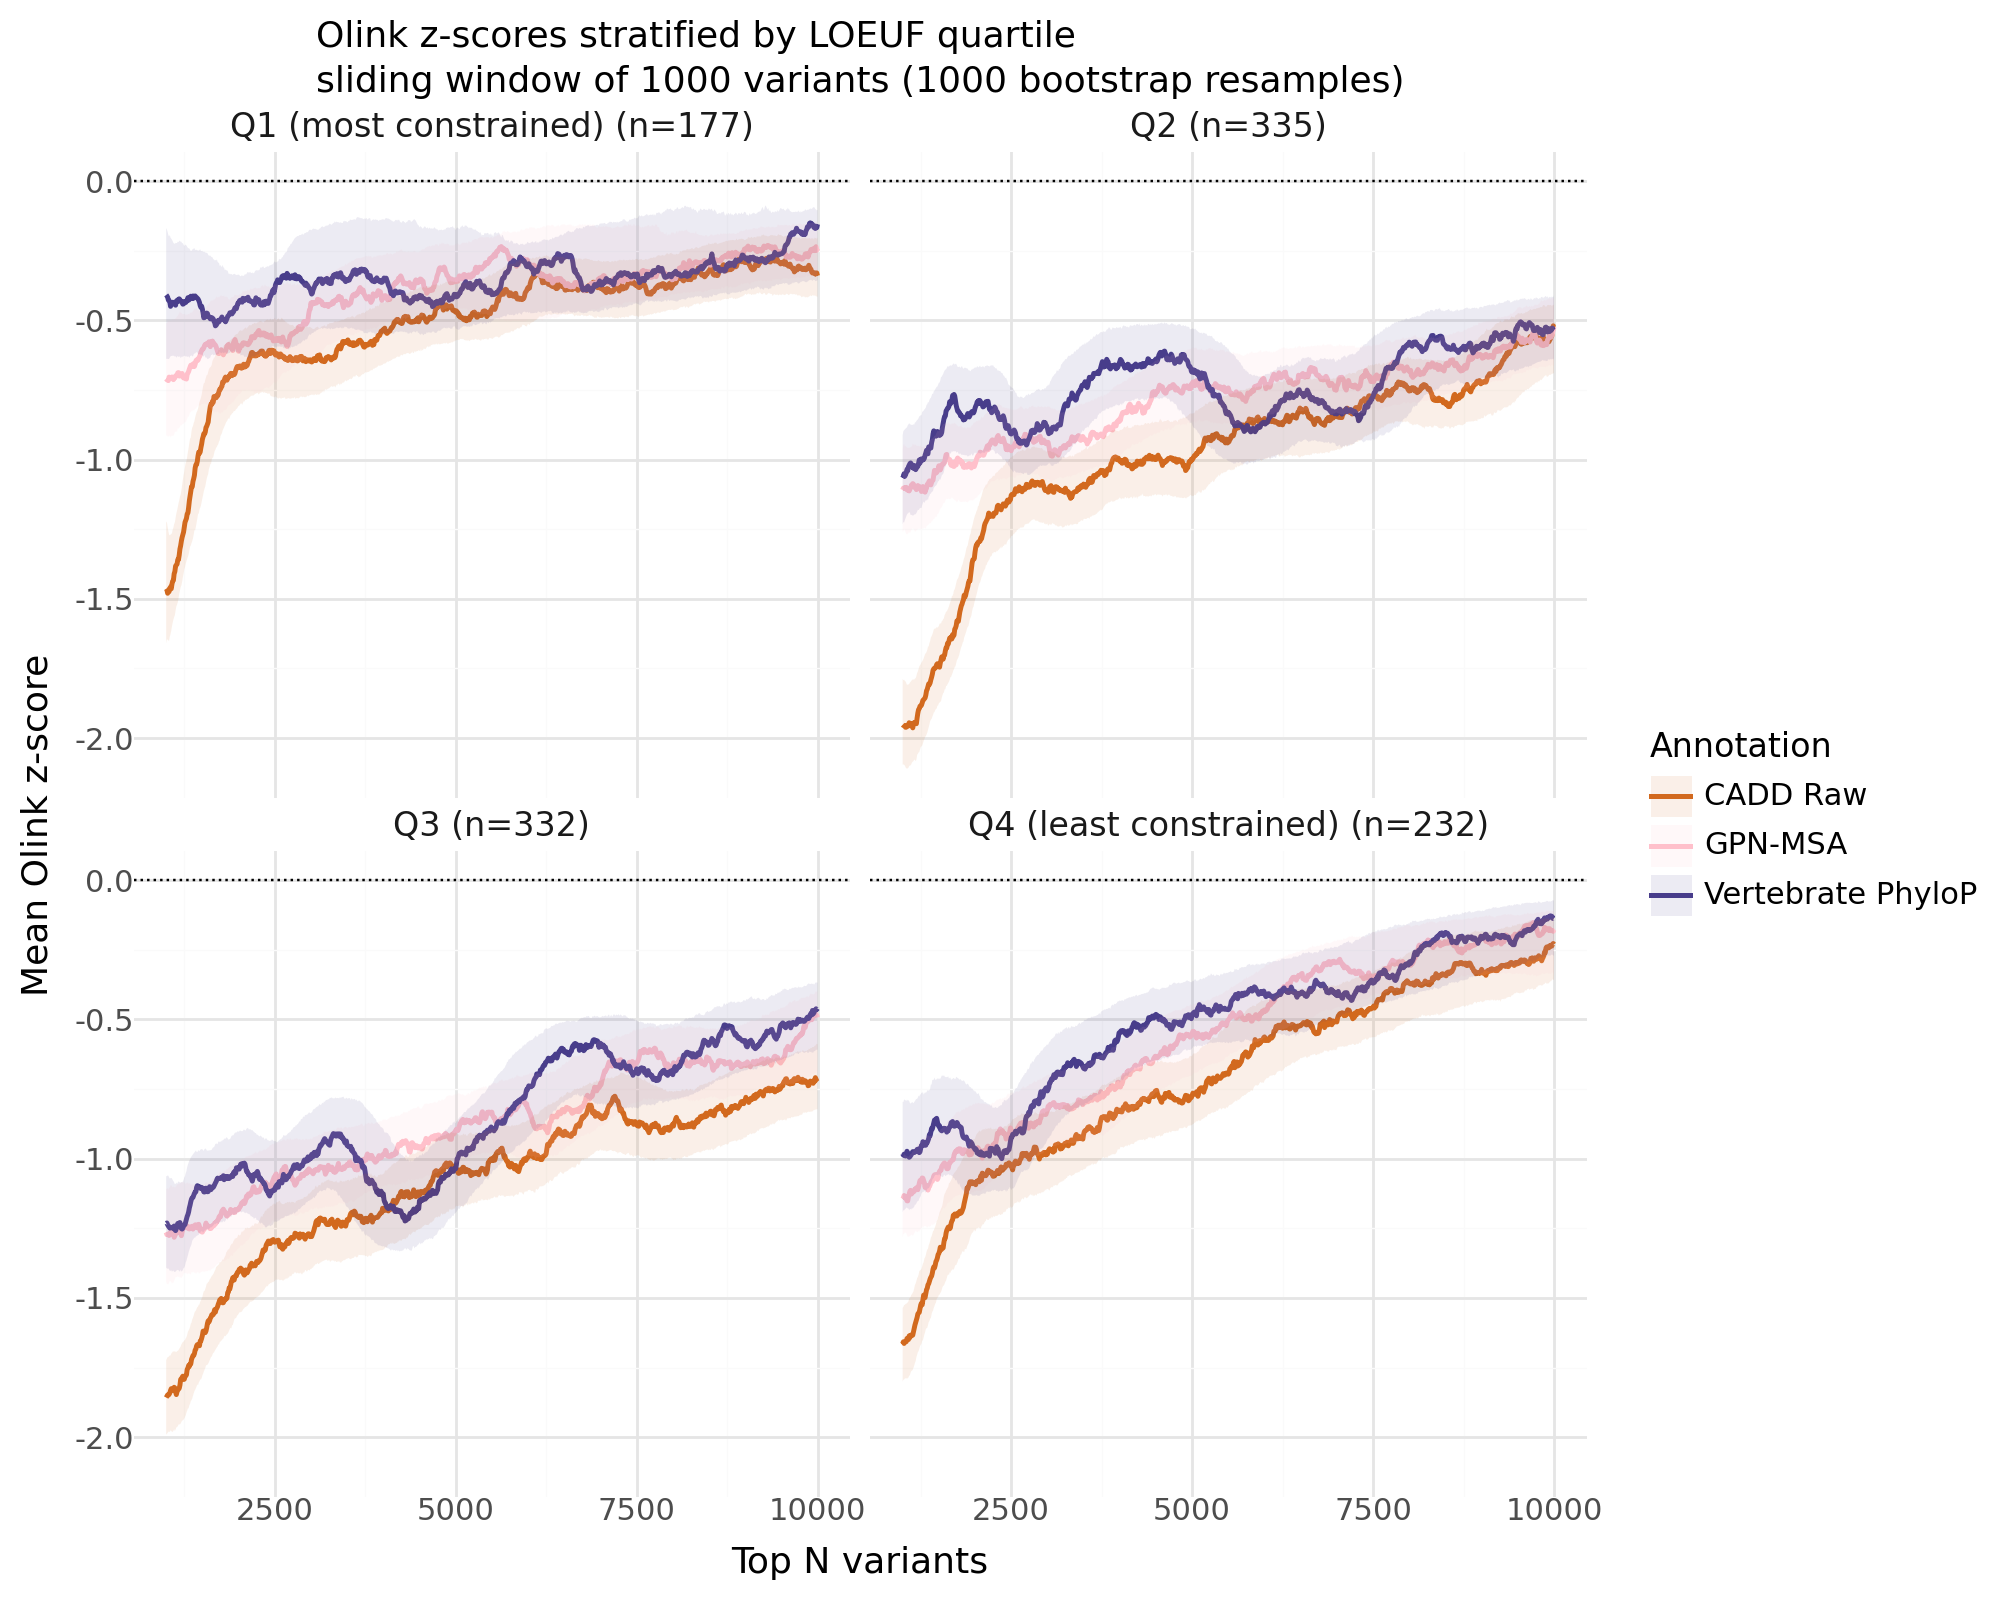

In [16]:
# x_label_ext = "Top N missense variants"
# x_label_ext = "Top N structured domain (missense) variants"
# x_label_ext = "Top N non-structured domain (missense) variants"
# x_label_ext = "Top N LIP domain (missense) variants"
# x_label_ext = "Top N intronic variants"
# x_label_ext = "Top N enhancer (pELS & dELS) variants"
# x_label_ext = "Top N promoter (PLS & CA-H3K4me3) variants"
# x_label_ext = "Top N TF binding region (TC & CA-TF) variants"
x_label_ext = "Top N variants"

plot_df = (
    plt_df
    .filter(
        (pl.col('bin_end') <= 10_000),

        # (pl.col('annotation').is_in(['promoterai', 'fz_all_min', 'abexp_min']))
        # (pl.col('annotation').is_in(['promoterai', 'fz_all_max']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense']))
    )
)

# Generate breaks and labels for x-axis (most extreme on the left)
max_rank = zscore_binned['bin_end'].max()
min_rank = zscore_binned['bin_end'].min()
start_exp = int(np.floor(np.log10(min_rank)))
end_exp = int(np.ceil(np.log10(max_rank)))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        plot_df,
        # aes(x='log_bin_end', y='mean_zscore')
        aes(x='bin_end', y='mean_zscore')
    )
    # + loftee_point
    + geom_hline(aes(yintercept=0), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    + facet_wrap("~loeuf_bin", ncol=2)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink z-scores stratified by LOEUF quartile\nsliding window of {window_size} variants ({n_boot} bootstrap resamples)",
        y="Mean Olink z-score",
        x=x_label_ext,
        color="Annotation",
        fill="Annotation",
    )
    # + scale_x_continuous(
    #     breaks=breaks_linear,
    #     labels=labels_sci
    # )
    + theme_minimal()
    + theme(
        figure_size=(10, 8),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=11),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=11),
        legend_title=element_text(size=12),
        strip_text=element_text(size=12),
        # legend_position='bottom',
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

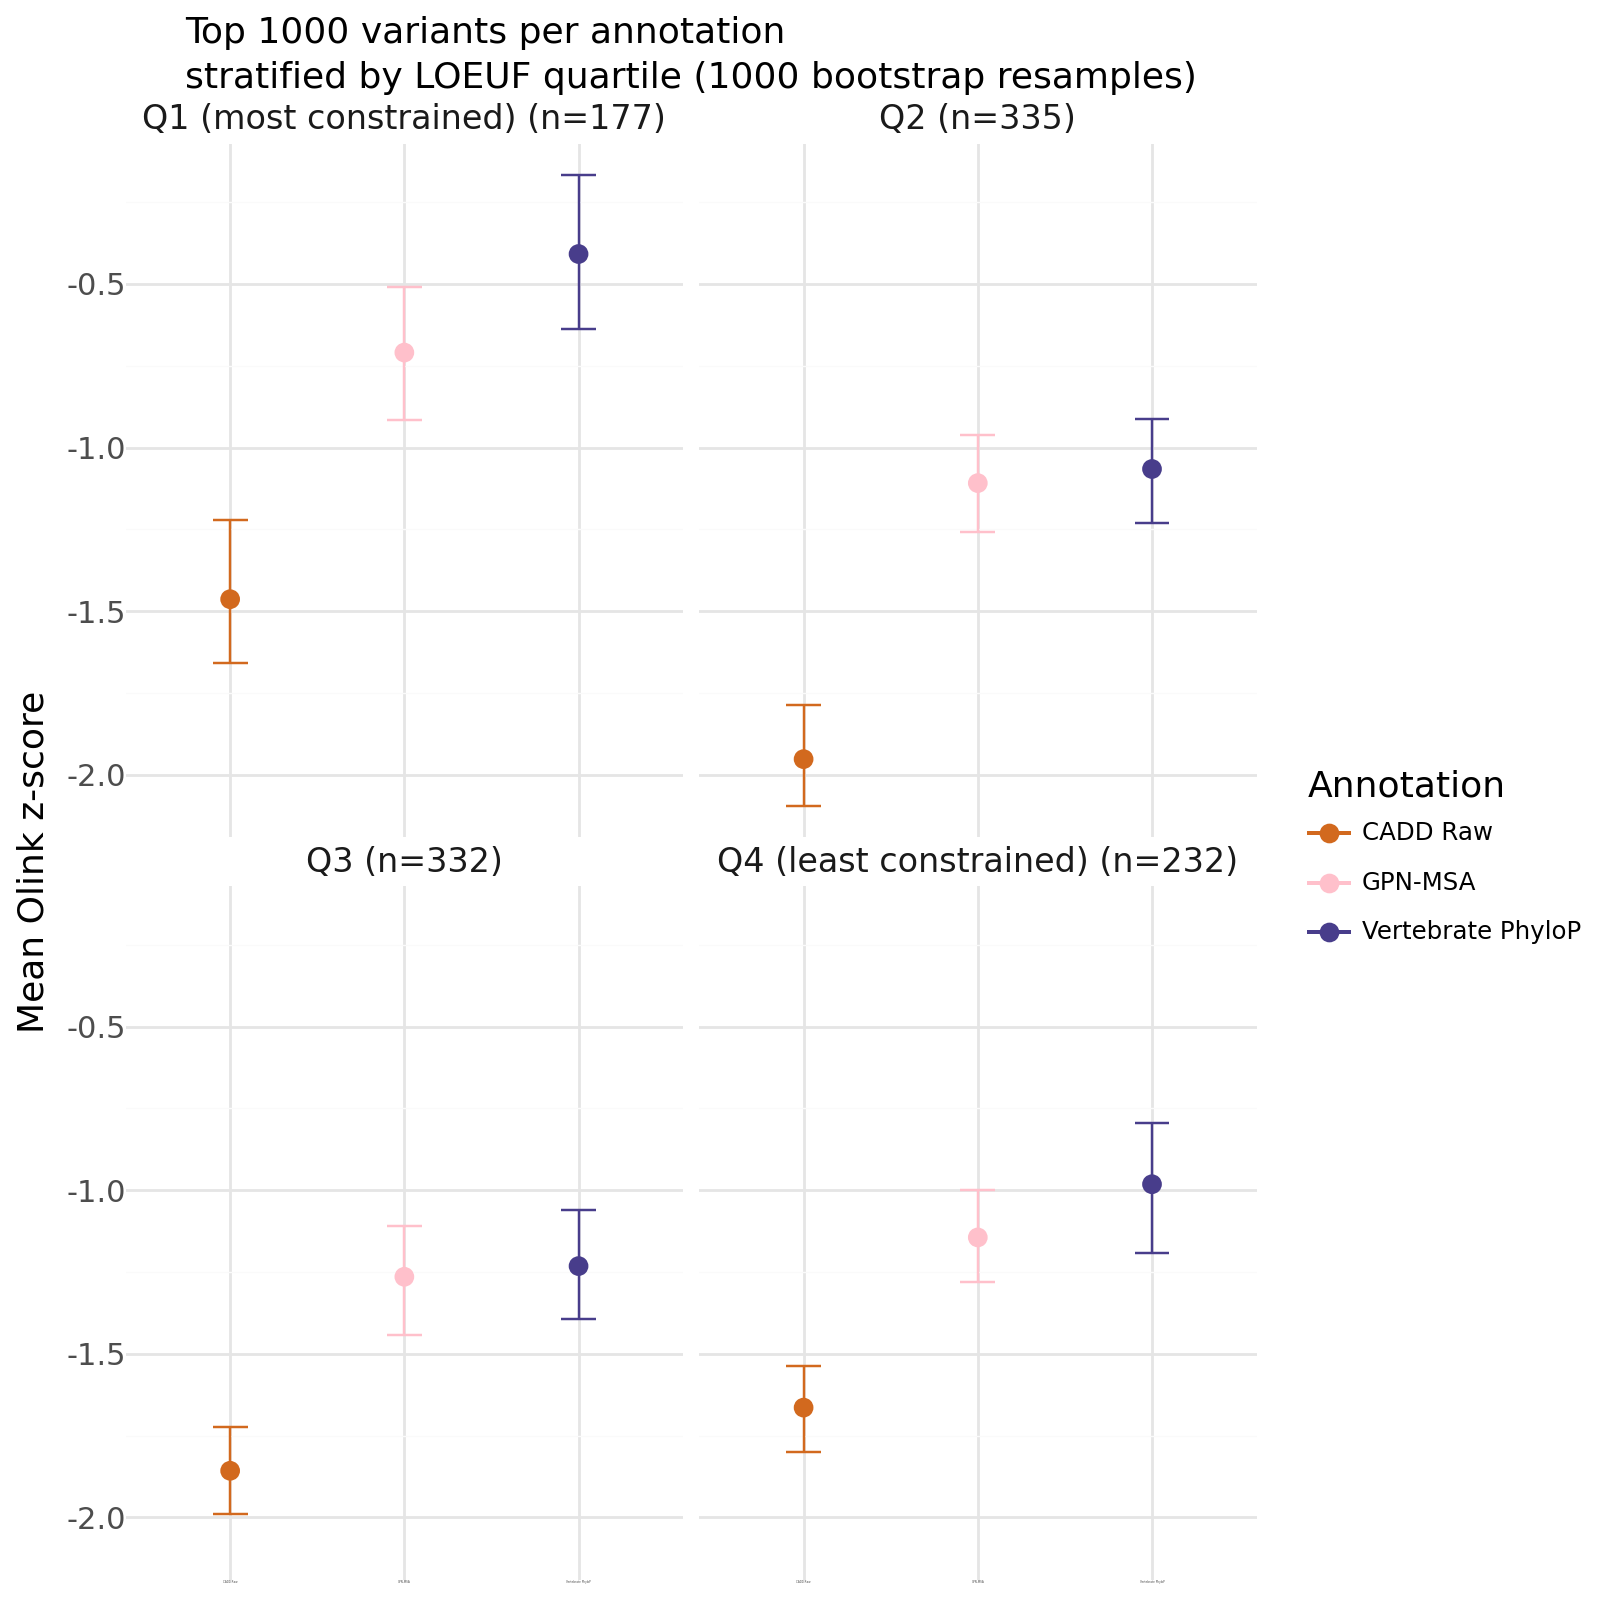

In [17]:
# Point plot: mean z-score of top window_size variants per annotation, faceted by LOEUF bin
point_df = (
    plot_df
    .filter(pl.col('bin_end') == float(window_size))
)

# Order annotations by mean z-score (averaged across LOEUF bins), descending
label_order = (
    point_df
    .group_by('label')
    .agg(pl.col('mean_zscore').mean())
    .sort('mean_zscore', descending=False)
    ['label'].to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))

(
    ggplot(
        point_df,
        aes(x='label', y='mean_zscore', color='label')
    )
    # + geom_hline(aes(yintercept=0), color='grey', linetype='dotted')
    + geom_point(size=3)
    + geom_errorbar(aes(ymin='ci_lower', ymax='ci_upper'), width=0.2)
    + facet_wrap("~loeuf_bin", ncol=2)
    + scale_color_manual(values=color_dict)
    + scale_x_discrete(limits=label_order)
    # + coord_flip()
    + labs(
        title=f"Top {window_size} variants per annotation\nstratified by LOEUF quartile ({n_boot} bootstrap resamples)",
        y="Mean Olink z-score",
        x="",
        fill="Annotation",
        color="Annotation",
    )
    + guides(color=None)
    + theme_minimal()
    + theme(
        figure_size=(8, 8),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=11),
        axis_text_x=element_text(size=0),
        axis_title=element_text(size=13),
        strip_text=element_text(size=12),
        plot_background=element_rect(fill="white", color="white"),
    )
)